---
# Réseau Fibre — Classification par cadastre & voiries
### Communes : Beaumarchés & Samatan
---

## 0 · Imports & Configuration

In [1]:
import os
import warnings
import geopandas as gpd
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore", "GeoSeries.notna", UserWarning)

# ── Racine commune à tous les chemins ──────────────────────────
BASE = os.path.dirname(os.path.abspath("__file__"))
# Si le notebook est dans C:\CDC_SIG_IA\GERS_Numerique\classif cadastre
# BASE pointe automatiquement vers ce dossier.
# Sinon, décommentez et adaptez la ligne ci-dessous :
# BASE = r"C:\CDC_SIG_IA\GERS_Numerique\classif cadastre"

print(f"✅ Imports OK")
print(f"📁 Répertoire de travail : {BASE}")

✅ Imports OK
📁 Répertoire de travail : c:\CDC_SIG_IA\GERS_Numerique\classif cadastre


---
## 1 · Chargement des tronçons fibre (après classification cadastre)

### 1.1 · Lecture des shapefiles

In [2]:
beaumarche_public = gpd.read_file(os.path.join(BASE, "Troncons_apres_classif", "Commune beaumarche", "public",  "troncons_public_caastre_beaumarche.shp"))
beaumarche_prive  = gpd.read_file(os.path.join(BASE, "Troncons_apres_classif", "Commune beaumarche", "prive",   "troncons_prive_cadastre_beaumarche.shp"))
samatan_public    = gpd.read_file(os.path.join(BASE, "Troncons_apres_classif", "Commune Samatan",    "public",  "troncons_public_caastre_samatan (1).shp"))
samatan_prive     = gpd.read_file(os.path.join(BASE, "Troncons_apres_classif", "Commune Samatan",    "prive",   "troncons_prive_cadastre_samatan (1).shp"))

beaumarche_public["commune"] = "Beaumarche"
beaumarche_prive["commune"]  = "Beaumarche"
samatan_public["commune"]    = "Samatan"
samatan_prive["commune"]     = "Samatan"

print(f"Beaumarchés public  : {len(beaumarche_public):>5} lignes")
print(f"Beaumarchés privé   : {len(beaumarche_prive):>5} lignes")
print(f"Samatan public      : {len(samatan_public):>5} lignes")
print(f"Samatan privé       : {len(samatan_prive):>5} lignes")
print(f"Total brut          : {len(beaumarche_public)+len(beaumarche_prive)+len(samatan_public)+len(samatan_prive):>5} lignes")

Beaumarchés public  :  1299 lignes
Beaumarchés privé   :  1226 lignes
Samatan public      :  2982 lignes
Samatan privé       :   962 lignes
Total brut          :  6469 lignes


### 1.2 · Concaténation par commune (public + privé)

In [3]:
df_beaumarche = pd.concat([beaumarche_public, beaumarche_prive], axis=0, ignore_index=True)
df_samatan    = pd.concat([samatan_public,    samatan_prive],    axis=0, ignore_index=True)

df_beaumarche.info()
print()
df_samatan.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2525 entries, 0 to 2524
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cm_code     2525 non-null   object  
 1   cm_tr       241 non-null    object  
 2   cm_d1       259 non-null    object  
 3   cm_d2       2356 non-null   object  
 4   cm_support  2525 non-null   object  
 5   cm_cb_tr    241 non-null    object  
 6   cm_cb_d1    259 non-null    object  
 7   cm_cb_d2    2356 non-null   object  
 8   cm_long     2525 non-null   float64 
 9   zanro       2525 non-null   object  
 10  zapm        2525 non-null   object  
 11  zapa        2525 non-null   object  
 12  domaine     2525 non-null   object  
 13  wkt         2525 non-null   object  
 14  wkt_line    2525 non-null   object  
 15  type_class  2525 non-null   object  
 16  geometry    2525 non-null   geometry
 17  commune     2525 non-null   object  
dtypes: float64(1), geometry(1), object(16)
m

---
## 2 · Géométries administratives (communes & département)

### 2.1 · Chargement du GeoPackage AdminExpress

In [4]:
gpkg_path   = os.path.join(BASE, "adminexpress-cog-simpl-000-2025.gpkg")
departements = gpd.read_file(gpkg_path, layer="departement")
communes     = gpd.read_file(gpkg_path, layer="commune")

print(f"Départements : {len(departements)} | Communes : {len(communes)}")

Départements : 103 | Communes : 34877


### 2.2 · Sélection du Gers et des communes cibles

In [5]:
gers         = departements[departements["insee_dep"] == "32"]
codes        = ["32410", "32036"]   # Samatan, Beaumarchès
communes_sel = communes[communes["insee_com"].isin(codes)]

print(gers[["insee_dep","nom","geometry"]])
print()
print(communes_sel[["insee_com","nom","geometry"]])

   insee_dep   nom                                           geometry
29        32  Gers  POLYGON ((0.74958 43.39849, 0.75502 43.40464, ...

      insee_com          nom  \
19986     32036  Beaumarchés   
31218     32410      Samatan   

                                                geometry  
19986  POLYGON ((0.12891 43.55439, 0.13609 43.55675, ...  
31218  POLYGON ((0.93802 43.46762, 0.94317 43.46741, ...  


### 2.3 · Association des géométries aux tronçons

In [6]:
geom_beaumarche = communes_sel.loc[communes_sel["insee_com"] == "32036", "geometry"].iloc[0]
geom_samatan    = communes_sel.loc[communes_sel["insee_com"] == "32410", "geometry"].iloc[0]
geom_gers       = gers["geometry"].iloc[0]

df_beaumarche["geometry_commune"]     = geom_beaumarche
df_samatan["geometry_commune"]        = geom_samatan
df_beaumarche["geometry_departement"] = geom_gers
df_samatan["geometry_departement"]    = geom_gers

df_final = pd.concat([df_beaumarche, df_samatan], axis=0, ignore_index=True)
df_final = df_final.rename(columns={"geometry": "geometry_tronçon"})
print(f"df_final : {len(df_final)} lignes | {len(df_final.columns)} colonnes")
df_final.head()

df_final : 6469 lignes | 20 colonnes


,cm_code,cm_tr,cm_d1,cm_d2,cm_support,cm_cb_tr,cm_cb_d1,cm_cb_d2,cm_long,zanro,zapm,zapa,domaine,wkt,wkt_line,type_class,geometry_tronçon,commune,geometry_commune,geometry_departement
0,00381/32319_00036/32163_918,TR,None,None,Souterrain RIP RAF,48 + 48,None,None,917.68,PLK,32163/PLK/PMZ/10589,32163/PLK/PA/13179,Public,LINESTRING (0.0311989573662925 43.587932600697...,LINESTRING (0.0311989573662925 43.587932600697...,classification par cadastres,"LINESTRING (460218.619 6281049.764, 460224.546...",Beaumarche,"POLYGON ((0.1289051 43.554389099999995, 0.1360...","POLYGON ((0.7495809999999999 43.398492, 0.7550..."
1,00381/32319_00036/32163_918,TR,None,None,Souterrain RIP RAF,48 + 48,None,None,917.68,PLK,32319/PLK/PMZ/10591,32319/PLK/PA/13190,Public,LINESTRING (0.0311989573662925 43.587932600697...,LINESTRING (0.0311989573662925 43.587932600697...,classification par cadastres,"LINESTRING (460218.619 6281049.764, 460224.546...",Beaumarche,"POLYGON ((0.1289051 43.554389099999995, 0.1360...","POLYGON ((0.7495809999999999 43.398492, 0.7550..."
2,0776999/32319_E000054/32319_38,None,None,D2,Aerien Enedis,None,None,12,38.29,PLK,32319/PLK/PMZ/10591,32319/PLK/PA/13187,Public,LINESTRING (0.0307066999999992 43.600357599999...,LINESTRING (0.0307066999999992 43.600357599999...,classification par cadastres,"LINESTRING (460230.796 6282431.206, 460239.783...",Beaumarche,"POLYGON ((0.1289051 43.554389099999995, 0.1360...","POLYGON ((0.7495809999999999 43.398492, 0.7550..."
3,0776998/32319_0776999/32319_34,None,None,D2,Aerien Orange,None,None,12,34.21,PLK,32319/PLK/PMZ/10591,32319/PLK/PA/13187,Public,"LINESTRING (0.0305362000000005 43.6006394, 0.0...","LINESTRING (0.0305362000000005 43.6006394, 0.0...",classification par cadastres,"LINESTRING (460218.212 6282463.021, 460218.871...",Beaumarche,"POLYGON ((0.1289051 43.554389099999995, 0.1360...","POLYGON ((0.7495809999999999 43.398492, 0.7550..."
4,0776998/32319_00380/32319_20,None,None,D2,Aero-souterrain RIP,None,None,12,19.84,PLK,32319/PLK/PMZ/10591,32319/PLK/PA/13187,Public,"LINESTRING (0.0305362000000005 43.6006394, 0.0...","LINESTRING (0.0305362000000005 43.6006394, 0.0...",classification par cadastres,"LINESTRING (460218.212 6282463.021, 460206.829...",Beaumarche,"POLYGON ((0.1289051 43.554389099999995, 0.1360...","POLYGON ((0.7495809999999999 43.398492, 0.7550..."


---
## 3 · Calcul de la redevance

In [7]:
supports_40 = {"Aerien Enedis","Aerien Orange","Aerien RIP",
               "Aero-souterrain Orange","Aero-souterrain RIP",
               "Aero-souterrain Tiers","Facade"}
supports_30 = {"Souterrain Orange","Souterrain RIP Construit",
               "Souterrain RIP RAF","Souterrain Tiers"}

df_final["longueur_km"] = df_final["cm_long"] / 100_000

df_final["tarif_km"] = np.select(
    [df_final["cm_support"].isin(supports_40),
     df_final["cm_support"].isin(supports_30),
     df_final["cm_support"] == "sans_tag"],
    [40, 30, 20],
    default=np.nan
)

df_final["montant_redevance"] = df_final["longueur_km"] * df_final["tarif_km"]

print(f"Montant total redevance : {df_final['montant_redevance'].sum():.2f} €")
df_final[["cm_long","longueur_km","cm_support","tarif_km","montant_redevance"]].head()

Montant total redevance : 154.82 €


,cm_long,longueur_km,cm_support,tarif_km,montant_redevance
0,917.68,0.009177,Souterrain RIP RAF,30.0,0.275304
1,917.68,0.009177,Souterrain RIP RAF,30.0,0.275304
2,38.29,0.000383,Aerien Enedis,40.0,0.015316
3,34.21,0.000342,Aerien Orange,40.0,0.013684
4,19.84,0.000198,Aero-souterrain RIP,40.0,0.007936


---
## 4 · Couche cadastre

### 4.1 · Chargement

In [8]:
gdf = gpd.read_file(os.path.join(BASE, "Couche cadastre", "parcelles.shp"))
gdf.head()

,id,commune,prefixe,section,numero,contenance,created,updated,geometry
0,320010000A0010,32001,000,A,10,78032,2008-01-04,2023-01-17,"POLYGON ((462705.331 6297415.472, 462703.671 6..."
1,320010000A0108,32001,000,A,108,22769,2008-01-04,2023-01-17,"POLYGON ((464184.057 6296383.548, 464180.840 6..."
2,320010000A0016,32001,000,A,16,80756,2008-01-04,2023-01-17,"POLYGON ((463160.512 6297509.096, 463206.787 6..."
3,320010000A0012,32001,000,A,12,62057,2008-01-04,2023-01-17,"POLYGON ((463072.849 6296971.349, 463103.410 6..."
4,320010000A0203,32001,000,A,203,26648,2008-01-04,2023-01-17,"POLYGON ((462540.349 6296587.883, 462552.341 6..."


### 4.2 · Sélection des communes voisines (niveaux 1 & 2)

Communes départ   : 2
Voisins niveau 1  : 20
Voisins niveau 2  : 38
Total conservé    : 58


<Axes: >

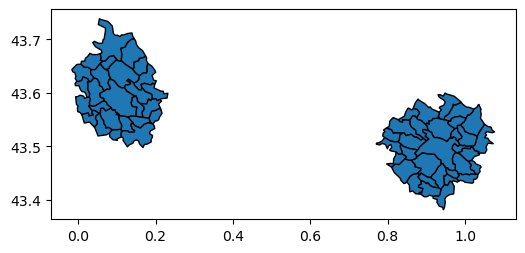

In [9]:
communes_gers = communes.to_crs(communes_sel.crs)
geom_depart   = communes_sel.unary_union

voisins_n1 = communes_gers[communes_gers.geometry.touches(geom_depart)]
geom_n1    = voisins_n1.unary_union
voisins_n2 = communes_gers[communes_gers.geometry.touches(geom_n1)]

communes_utiles = communes_gers.loc[
    communes_gers.index.isin(communes_sel.index) |
    communes_gers.index.isin(voisins_n1.index)   |
    communes_gers.index.isin(voisins_n2.index)
].copy()

print(f"Communes départ   : {len(communes_sel)}")
print(f"Voisins niveau 1  : {len(voisins_n1)}")
print(f"Voisins niveau 2  : {len(voisins_n2)}")
print(f"Total conservé    : {len(communes_utiles)}")
communes_utiles.plot(edgecolor="black", figsize=(6, 6))

### 4.3 · Filtrage du cadastre

In [10]:
codes_utiles     = communes_utiles["insee_com"].unique()
cadastre_reduit  = gdf[gdf["commune"].isin(codes_utiles)].copy()
print(f"Cadastre avant filtre : {len(gdf)} | après : {len(cadastre_reduit)}")

Cadastre avant filtre : 868407 | après : 91338


---
## 5 · Couche voiries (nettoyée)

In [11]:
df_voiries_clean = gpd.read_file(os.path.join(BASE, "Couche_voiries", "voiries_clean.shp"))
print(f"Voiries : {len(df_voiries_clean)} polygones")
print(f"NATURE      : {df_voiries_clean['NATURE'].unique()}")
print(f"Gestionnai  : {df_voiries_clean['Gestionnai'].unique()}")
df_voiries_clean.head()

Voiries : 2605 polygones
NATURE      : ['Route à 1 chaussée' 'Route empierrée' 'Chemin' 'Escalier' 'Sentier'
 'Rond-point' 'Route à 2 chaussées']
Gestionnai  : ['Département' 'Commune']


,ID,NATURE,Gestionnai,geometry
0,TRONROUT0000000111241130,Route à 1 chaussée,Département,"POLYGON ((465691.939 6284269.138, 465690.775 6..."
1,TRONROUT0000000111241137,Route empierrée,Commune,"MULTIPOLYGON (((464890.976 6284082.555, 464925..."
2,TRONROUT0000000111241138,Route à 1 chaussée,Département,"MULTIPOLYGON (((464969.734 6284109.642, 464998..."
3,TRONROUT0000000111241139,Route à 1 chaussée,Département,"MULTIPOLYGON (((464841.130 6284065.946, 464841..."
4,TRONROUT0000000111241141,Chemin,Commune,"MULTIPOLYGON (((464890.661 6284642.741, 464951..."


---
## 6 · Segmentation des tronçons fibre par voiries

In [12]:
# ── Préparation ───────────────────────────────────────────────
df_final_geo         = df_final.set_geometry("geometry_tronçon").copy()
df_final_geo_overlay = df_final_geo.rename_geometry("geometry")
df_final_geo_overlay["longueur_geom_originale"] = df_final_geo_overlay.geometry.length

print(f"CRS df_final      : {df_final_geo_overlay.crs}")
print(f"CRS voiries_clean : {df_voiries_clean.crs}")

if df_final_geo_overlay.crs != df_voiries_clean.crs:
    df_voiries_clean = df_voiries_clean.to_crs(df_final_geo_overlay.crs)
    print("⚠️ Reprojection effectuée sur df_voiries_clean")

voiries_join = df_voiries_clean.rename(columns={"ID": "voirie_id"}).copy()

# ── Overlay : découpage fibre × voiries ───────────────────────
df_decoupage = gpd.overlay(df_final_geo_overlay, voiries_join, how="intersection", keep_geom_type=True)
df_decoupage = df_decoupage[~df_decoupage.geometry.is_empty & df_decoupage.geometry.notna()].copy().reset_index(drop=True)

# ── Tronçons hors voiries ─────────────────────────────────────
voiries_union_geom                               = df_voiries_clean.geometry.unary_union
df_final_geo_overlay["geometry_hors_voirie"]     = df_final_geo_overlay.geometry.difference(voiries_union_geom)

df_hors_voirie = df_final_geo_overlay[
    ~df_final_geo_overlay["geometry_hors_voirie"].is_empty &
     df_final_geo_overlay["geometry_hors_voirie"].notna()
].copy()

df_hors_voirie["geometry"]   = df_hors_voirie["geometry_hors_voirie"]
df_hors_voirie               = df_hors_voirie.drop(columns=["geometry_hors_voirie"])
df_hors_voirie["voirie_id"]  = None
df_hors_voirie["NATURE"]     = "Hors voirie"
df_hors_voirie["Gestionnai"] = "Inconnu"
df_hors_voirie               = gpd.GeoDataFrame(df_hors_voirie, geometry="geometry", crs=df_final_geo_overlay.crs)

# ── Concaténation & nettoyage ─────────────────────────────────
df_final_decoupage = pd.concat([df_decoupage, df_hors_voirie], axis=0, ignore_index=True)
df_final_decoupage = df_final_decoupage[
    ~df_final_decoupage.geometry.is_empty & df_final_decoupage.geometry.notna()
].copy().reset_index(drop=True)

# ── Recalcul cm_long / longueur_km / montant (proportionnel) ──
df_final_decoupage["longueur_geom_fragment"] = df_final_decoupage.geometry.length

df_final_decoupage["cm_long"] = (
    df_final_decoupage["cm_long"] *
    (df_final_decoupage["longueur_geom_fragment"] / df_final_decoupage["longueur_geom_originale"])
)
df_final_decoupage["longueur_km"]       = df_final_decoupage["cm_long"] / 100_000
df_final_decoupage["tarif_km"]          = np.select(
    [df_final_decoupage["cm_support"].isin(supports_40),
     df_final_decoupage["cm_support"].isin(supports_30),
     df_final_decoupage["cm_support"] == "sans_tag"],
    [40, 30, 20], default=np.nan
)
df_final_decoupage["montant_redevance"]  = df_final_decoupage["longueur_km"] * df_final_decoupage["tarif_km"]
df_final_decoupage = df_final_decoupage.drop(columns=["longueur_geom_fragment","longueur_geom_originale"], errors="ignore")

print(f"Tronçons avant découpage : {len(df_final_geo_overlay)}")
print(f"Fragments dans voiries   : {len(df_decoupage)}")
print(f"Fragments hors voiries   : {len(df_hors_voirie)}")

CRS df_final      : EPSG:2154
CRS voiries_clean : EPSG:2154
Tronçons avant découpage : 6469
Fragments dans voiries   : 6589
Fragments hors voiries   : 3861


---
## 7 · Vérification des totaux (avant / après segmentation)

In [13]:
longueur_avant = df_final["longueur_km"].sum()
longueur_apres = df_final_decoupage["longueur_km"].sum()
montant_avant  = df_final["montant_redevance"].sum()
montant_apres  = df_final_decoupage["montant_redevance"].sum()

print("=" * 55)
print(f"  Tronçons avant  : {len(df_final):>10}")
print(f"  Tronçons après  : {len(df_final_decoupage):>10}")
print("-" * 55)
print(f"  Longueur avant (km) : {longueur_avant:>10.3f}")
print(f"  Longueur après (km) : {longueur_apres:>10.3f}")
print(f"  Écart               : {abs(longueur_avant - longueur_apres):>10.4f}  ← doit être ~0")
print("-" * 55)
print(f"  Montant avant  : {montant_avant:>10.2f} €")
print(f"  Montant après  : {montant_apres:>10.2f} €")
print(f"  Écart          : {abs(montant_avant - montant_apres):>10.4f} €  ← doit être ~0")
print("=" * 55)

  Tronçons avant  :       6469
  Tronçons après  :      10450
-------------------------------------------------------
  Longueur avant (km) :      4.656
  Longueur après (km) :      4.652
  Écart               :     0.0039  ← doit être ~0
-------------------------------------------------------
  Montant avant  :     154.82 €
  Montant après  :     154.64 €
  Écart          :     0.1723 €  ← doit être ~0


---
## 8 · Analyses statistiques

In [15]:
def analyse(df, groupby_cols, titre):
    separateur = "=" * 60
    print("")
    print(separateur)
    print(f"  {titre}")
    print(separateur)
    result = (
        df.groupby(groupby_cols, dropna=False)
        .agg(
            nb_troncons   = ("cm_long",          "count"),
            longueur_km   = ("longueur_km",       "sum"),
            montant_total = ("montant_redevance", "sum")
        )
        .round(3)
        .sort_values("montant_total", ascending=False)
    )
    print(result)
    return result

analyse_gest            = analyse(df_final_decoupage, "Gestionnai",                       "Par gestionnaire")
analyse_nature          = analyse(df_final_decoupage, "NATURE",                           "Par nature de voirie")
analyse_croisee         = analyse(df_final_decoupage, ["Gestionnai", "NATURE", "cm_support"], "Gestionnaire × Nature × Support")
analyse_domaine         = analyse(df_final_decoupage, "domaine",                          "Par domaine (Public / Privé)")
analyse_hors_voirie_dom = analyse(df_final_decoupage[df_final_decoupage["NATURE"] == "Hors voirie"], "domaine", "Hors voirie × Domaine")
analyse_nature_domaine  = analyse(df_final_decoupage, ["NATURE", "domaine"],              "Nature × Domaine")
analyse_gest_domaine    = analyse(df_final_decoupage, ["Gestionnai", "domaine"],          "Gestionnaire × Domaine")


  Par gestionnaire
             nb_troncons  longueur_km  montant_total
Gestionnai                                          
Inconnu             3861        2.225         74.676
Commune             4237        1.203         42.181
Département         2352        1.224         37.787

  Par nature de voirie
                     nb_troncons  longueur_km  montant_total
NATURE                                                      
Route à 1 chaussée          6154        2.312         76.162
Hors voirie                 3861        2.225         74.676
Route empierrée              214        0.071          2.350
Chemin                       122        0.020          0.721
Route à 2 chaussées           41        0.011          0.329
Rond-point                    19        0.007          0.205
Sentier                       31        0.005          0.147
Escalier                       8        0.002          0.055

  Gestionnaire × Nature × Support
                                              

---
## 9 · Export Shapefile

In [16]:
output_path = os.path.join(BASE, "result", "troncons_classes_voiries.shp")
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df_export = gpd.GeoDataFrame(
    df_final_decoupage.drop(columns=["geometry_commune","geometry_departement"], errors="ignore"),
    geometry="geometry",
    crs=df_final_decoupage.crs
)

df_export.to_file(output_path, driver="ESRI Shapefile", encoding="utf-8")

print(f"✅ Shapefile exporté : {output_path}")
print(f"   Lignes   : {len(df_export)}")
print(f"   Colonnes : {list(df_export.columns)}")

C:\Users\a900694\AppData\Local\Temp\ipykernel_25812\3485612626.py:10: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  df_export.to_file(output_path, driver="ESRI Shapefile", encoding="utf-8")


✅ Shapefile exporté : c:\CDC_SIG_IA\GERS_Numerique\classif cadastre\result\troncons_classes_voiries.shp
   Lignes   : 10450
   Colonnes : ['cm_code', 'cm_tr', 'cm_d1', 'cm_d2', 'cm_support', 'cm_cb_tr', 'cm_cb_d1', 'cm_cb_d2', 'cm_long', 'zanro', 'zapm', 'zapa', 'domaine', 'wkt', 'wkt_line', 'type_class', 'commune', 'longueur_km', 'tarif_km', 'montant_redevance', 'voirie_id', 'NATURE', 'Gestionnai', 'geometry']
